Write your solution in here.

- Your code has to reference all data files using **relative** paths so that they can be loaded on other computers without modifications.
- All data files need to be stored in the `data/` folder.

For example: (REMOVE THIS)

In [350]:
import pandas as pd

# Define the path to the data directory
DATA_PATH = './data'

# Read the CSV using a relative path
df = pd.read_csv(f'{DATA_PATH}/sce_extract_2015.csv')

# Term Paper 2 - Expectations about Macroeconomic and Financial Variables

### Initial Setup - Modules, Display options, Data Path

In [351]:
# Modules
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
# Scikit-learn modules for regression and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# Set display options for better readability
pd.set_option('display.max_columns', 50)

# Define the path to the data directory
DATA_PATH = './data'

## Part 1 - Data Preprocessing (SCE)

In [352]:
# Step 1 - Import and merge SCE data from all waves, keeping only relevant columns and parsing dates

# Variables with large share of NAs where dropped before implementing final solution

# Variables asked only at the first interview → need forward-filling
COLS_FIRST_WAVE = [
    'owner',
    'num_lit_q1_correct', 'num_lit_q2_correct', 'num_lit_q3_correct',
    'num_lit_q5_correct', 'num_lit_q6_correct'
]

# Variables related to expectations → need outlier treatment
COLS_EXPECTATIONS = ['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']

# Variables related to individual characteristics → no cleaning needed
COLS_INDIVIDUAL = [
    'female', 'hispanic', 'black', 'educ',
    'hh_inc_bin_rank', 'working', 'couple', 'num_kids', 'age_init'
]

# Variables to keep for analysis (expectations + first-wave + individual characteristics)
ANALYSIS_COLS = COLS_EXPECTATIONS + COLS_FIRST_WAVE + COLS_INDIVIDUAL

# Metadata columns to keep for merging and panel structure (Weight dropped - not needed for analysis, not compatible with all scikit-learn methods)
COLS_META = ['userid', 'wid', 'date', 'tenure']

# All variables to read from the CSV files (Defined before reading files to avoid reading unnecessary columns)
ALL_COLS  = COLS_META + ANALYSIS_COLS

# Read and concatenate all CSV files, keeping only the relevant columns and parsing dates
files = sorted(glob.glob(f'{DATA_PATH}/sce_extract_*.csv'))

sce = pd.concat(
    [pd.read_csv(f, usecols=lambda c: c in ALL_COLS, parse_dates=['date']) for f in files],
    ignore_index=True
).sort_values(['userid', 'date']).reset_index(drop=True)

# Verify that all expected columns are present
assert set(ALL_COLS).issubset(sce.columns), (
    f"Missing columns: {set(ALL_COLS) - set(sce.columns)}"
)

# Initial data summary
n_obs_init   = len(sce)
n_ind_init   = sce['userid'].nunique()
n_waves_init = sce['wid'].nunique()

first_date_init = sce['date'].min().date()
last_date_init  = sce['date'].max().date()

print("=== Initial sample ===")
print(f"  Observations : {n_obs_init:,}")
print(f"  Individuals  : {n_ind_init:,}")
print(f"  Survey waves : {n_waves_init}")
print(f"  Date range   : {first_date_init} → {last_date_init}")

=== Initial sample ===
  Observations : 180,268
  Individuals  : 23,886
  Survey waves : 143
  Date range   : 2013-06-01 → 2025-05-01


The individual-level features were selected based on two criteria: economic relevance as predictors of expectations, and data availability. Several variables were excluded due to a high share of missing values (20% or more), which would have substantially reduced the sample size: num_lit_q8_correct, num_lit_q9_correct, take_fin_risk, health, and self_employed. The survey sampling weight was dropped since not all scikit-learn estimators support sample weights.
Variables asked only at the first interview (owner, age_init, and the numerical literacy indicators) are forward-filled within each individual so that later waves carry the value from the first wave. Other expectation-related variables (e.g. infl_3y, prob_irate_up) are excluded as predictors, since they would not be available to a policymaker trying to forecast expectations in real time.

age_init was recorded at first interview, but carried forward prior to our analysis, hence why it's not in COLS_FIRST_WAVE. 

In [353]:
# Step 2 - Forward-fill within each individual (only fills NaNs after the first observed value)
sce[COLS_FIRST_WAVE] = (
    sce.groupby('userid')[COLS_FIRST_WAVE].ffill()
)

In [354]:
# Step 3 - Drop observations from 2025 due to Trump-volatility
mask_2025 = sce['date'].dt.year == 2025
n_dropped_2025 = mask_2025.sum()
sce = sce[~mask_2025].copy()
print(f"Step 3 — Dropped {n_dropped_2025:,} observations from 2025")

Step 3 — Dropped 4,167 observations from 2025


In [355]:
# Step 4 - Drop observations with missing values in the analysis columns
n_before = len(sce)
sce = sce.dropna(subset=ANALYSIS_COLS).copy()
print(f"Step 4 — Dropped {n_before - len(sce):,} observations with missing values")

Step 4 — Dropped 16,966 observations with missing values


In [356]:
print((sce['prob_unrate_up'] == 0).sum())
print((sce['prob_unrate_up'] == 100).sum())

2679
1855


In [357]:
# Step 5 - Trimming outliers
# Compute all percentiles upfront on the full sample before any rows are dropped
percentiles = {col: (sce[col].quantile(0.01), sce[col].quantile(0.99)) for col in COLS_EXPECTATIONS}
obs_dropped_outliers = 0

for col in COLS_EXPECTATIONS:
    p1, p99 = percentiles[col]
    n_before = len(sce)
    sce = sce[(sce[col] > p1) & (sce[col] < p99)]
    print(f"  {col}: P1={p1:.2f}, P99={p99:.2f} → dropped {n_before - len(sce):,} obs")
    obs_dropped_outliers += n_before - len(sce)

# Reset index
sce = sce.reset_index(drop=True)

print('-' * 60)
print(f"Step 5 — Dropped a total of {obs_dropped_outliers:,} observations as outliers")

  infl_1y: P1=-30.00, P99=60.00 → dropped 3,400 obs
  house_price_change: P1=-20.00, P99=50.00 → dropped 3,790 obs
  prob_unrate_up: P1=0.00, P99=100.00 → dropped 4,034 obs
  prob_stocks_up: P1=0.00, P99=95.00 → dropped 2,394 obs
------------------------------------------------------------
Step 5 — Dropped a total of 13,618 observations as outliers


For prob_unrate_up, the 1st percentile is 0 and the 99th percentile is 100. Since the trimming condition is strictly > P1 and < P99, observations with values exactly equal to 0 or 100 are dropped. These are respondents who are completely certain about the direction of unemployment, which are valid responses rather than data errors - however, we follow the assignment instructions and apply the same rule to all four variables.
For prob_stocks_up, P99 = 95, meaning the top 1% of responses (above 95%) are removed as extreme outliers.

In [358]:
# Step 6 - Create Optimism indicators
sce['optimist_unrate']      = (sce['prob_unrate_up'] < 50).astype(int)
sce['optimist_stocks']      = (sce['prob_stocks_up'] > 50).astype(int)
sce['optimist_house_price'] = (sce['house_price_change'] > 0).astype(int)

# Store optimism indicators in a list for later use
OPTIMISM_COLS = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

In [359]:
# Data cleaning summary
summary = pd.DataFrame({
    'Sample'       : ['Initial', 'Final', 'Difference'],
    'Observations' : [n_obs_init, len(sce), len(sce) - n_obs_init],
    'Individuals'  : [n_ind_init, sce['userid'].nunique(), sce['userid'].nunique() - n_ind_init],
    'Survey waves' : [n_waves_init, sce['wid'].nunique(), sce['wid'].nunique() - n_waves_init],
    'First date'   : [first_date_init, sce['date'].min().date(), f'({(sce["date"].min().date() - first_date_init).days} days)'],
    'Last date'    : [last_date_init, sce['date'].max().date(), f'{(sce["date"].max().date() - last_date_init).days} days'],
})
display(summary)

,Sample,Observations,Individuals,Survey waves,First date,Last date
0,Initial,180268,23886,143,2013-06-01,2025-05-01
1,Final,145517,21783,139,2013-06-01,2024-12-31
2,Difference,-34751,-2103,-4,(0 days),-121 days


The final sample of $145,517$ observations is close to the target of ~$150,000$

## Part 2 - Data Preprocessing (Macro/Finance)

All macro and financial time series are downloaded and saved as CSV files in the `data/` folder.

**Yahoo Finance** data (WTI Crude Oil, S&P 500) was downloaded programmatically using `yfinance` and saved to CSV. **FRED** data (CPI, House Price Index, Federal Funds Rate, Unemployment Rate, Real GDP, USD Index, 30-Year Mortgage Rate) was downloaded manually from [fred.stlouisfed.org](https://fred.stlouisfed.org).

All series are resampled to **monthly frequency** and shifted forward by one month so that a respondent interviewed in month $t$ only sees data available through the end of month $t-1$. For quarterly series (GDP, House Price Index), forward-filling within the quarter ensures the latest available value is used.

Variables are included both in **levels** and as **12-month changes**:
- *Levels* capture the current macroeconomic environment (e.g., high unemployment may anchor pessimism about future unemployment).
- *12-month changes* capture recent momentum and surprises (e.g., a sharp rise in CPI may push inflation expectations higher regardless of the level).


Skriv tekst her

### Remember:

Motivate choice of variables in levels or relative/absolute 1-month/12-month differences.

NB! All of the above is also an option!

In [360]:
# Read and combine Yahoo data (downloaded programmatically and stored in the data directory as CSV files)
wti   = pd.read_csv(f'{DATA_PATH}/wti_crude_oil.csv', parse_dates=['date'], index_col='date')
sp500 = pd.read_csv(f'{DATA_PATH}/sp500.csv', parse_dates=['date'], index_col='date')

# Create a dictionary to hold the raw Yahoo Finance series
yahoo_series = {"wti_crude_oil": wti, "sp500": sp500}

# Initialize an empty list to store the monthly resampled dataframes
yahoo_m = []

# Resample to month-end frequency, compute returns, and shift by one month to avoid look-ahead bias
for col, raw in yahoo_series.items():
    m = raw.resample("ME").last()
    m[f"{col}_ret"]     = m[col].pct_change()
    m[f"{col}_ret_12m"] = m[col].pct_change(12)
    yahoo_m.append(m.shift(1))

# Concatenate all monthly resampled dataframes into a single DataFrame
yahoo_all = pd.concat(yahoo_m, axis=1)

# Overview of the final Yahoo Finance data after resampling and return calculations (Remove?)
display(yahoo_all.tail())

,wti_crude_oil,wti_crude_oil_ret,wti_crude_oil_ret_12m,sp500,sp500_ret,sp500_ret_12m
date,,,,,,
2024-08-31,77.910004,-0.044518,-0.047555,5522.299805,0.011321,0.203388
2024-09-30,73.550003,-0.055962,-0.120531,5648.399902,0.022835,0.253067
2024-10-31,68.169998,-0.073148,-0.249146,5762.479980,0.020197,0.343846
2024-11-30,69.260002,0.015989,-0.145149,5705.450195,-0.009897,0.360449
2024-12-31,68.000000,-0.018192,-0.104792,6032.379883,0.057301,0.320631


In [361]:
#  Read and combine FRED data (Downloaded manually and stored in the data directory as CSV files)

# Dictionary mapping variable names → (filename, resample method, forward-fill for quarterly series)
FRED_CONFIG = {
    "cpi":             ("CPIAUCSL.csv",     "last", False),
    "house_price_idx": ("USSTHPI.csv",      "last", True),
    "federal_funds":   ("FEDFUNDS.csv",     "mean", False),
    "unemployment":    ("UNRATE.csv",       "last", False),
    "real_gdp":        ("GDPC1.csv",        "last", True),
    "usd_index":       ("DTWEXBGS.csv",     "last", False),
    "mortgage_30y":    ("MORTGAGE30US.csv", "mean", False),
}
# Read, resample, and forward-fill FRED data as needed
macro_m = {}
for name, (fname, method, needs_ffill) in FRED_CONFIG.items():
    s = pd.read_csv(f"{DATA_PATH}/{fname}", parse_dates=[0], index_col=0,
                    header=0, names=['date', name])
    s = getattr(s.resample("ME"), method)()
    macro_m[name] = s.ffill() if needs_ffill else s

# CPI only: add year-on-year inflation rate
macro_m["cpi"]["cpi_yoy"] = macro_m["cpi"]["cpi"].pct_change(12, fill_method=None) * 100

# Apply timing rule (shift) and combine
macro_all = pd.concat([s.shift(1) for s in macro_m.values()], axis=1).sort_index()

# Keep only dates that overlap with survey data
macro_all = macro_all[(macro_all.index >= sce['date'].min()) & (macro_all.index <= sce['date'].max())]

# Overview of the final macroeconomic data after resampling and timing adjustments (Remove?)
display(macro_all.tail())

,cpi,cpi_yoy,house_price_idx,federal_funds,unemployment,real_gdp,usd_index,mortgage_30y
date,,,,,,,,
2024-08-31,313.569,2.941476,682.41,5.33,4.2,23478.570,123.6373,6.8475
2024-09-30,314.062,2.607144,682.41,5.33,4.2,23478.570,122.3262,6.5000
2024-10-31,314.732,2.426483,682.41,5.13,4.1,23478.570,121.2864,6.1800
2024-11-30,315.631,2.578844,685.93,4.83,4.1,23586.542,124.7988,6.4280
2024-12-31,316.528,2.719472,685.93,4.64,4.2,23586.542,126.5798,6.8050


In [362]:
# Merge Yahoo Finance data into the monthly macro panel
macro_all = macro_all.join(yahoo_all, how="left")
macro_all = macro_all.sort_index()

# Merge monthly macro panel into the SCE data using a month-end key.
# macro_all row at month-end t contains data available at end of month t-1 (due to shift(1)).
# A respondent interviewed on any day in month t should use this row.
sce['date_me'] = sce['date'] + pd.offsets.MonthEnd(0)

# Prepare macro_all for merging: reset date index into a column named 'date_me'
macro_for_merge = macro_all.rename_axis('date_me').reset_index()

# Left-join SCE with macro panel, then drop the temporary merge key
sce_data = sce.merge(macro_for_merge, on='date_me', how='left').drop(columns=['date_me'])

# Verify the merge worked correctly
print(f"SCE observations: {len(sce_data):}")
print(f"Macro panel observations: {len(macro_for_merge):,}")
print("\nSample of macro columns for first few rows:")
display(sce_data[['date', 'cpi', 'unemployment', 'sp500', 'wti_crude_oil']].tail())

# Report NaN rates in macro columns (should only be usd_index at the start of the sample)
macro_cols = macro_for_merge.columns.drop('date_me').tolist()

SCE observations: 145517
Macro panel observations: 139

Sample of macro columns for first few rows:


,date,cpi,unemployment,sp500,wti_crude_oil
145512,2024-12-19,316.528,4.2,6032.379883,68.0
145513,2024-12-02,316.528,4.2,6032.379883,68.0
145514,2024-12-20,316.528,4.2,6032.379883,68.0
145515,2024-12-05,316.528,4.2,6032.379883,68.0
145516,2024-12-12,316.528,4.2,6032.379883,68.0


## Part 3 - Exploratory Data Analysis (SCE)

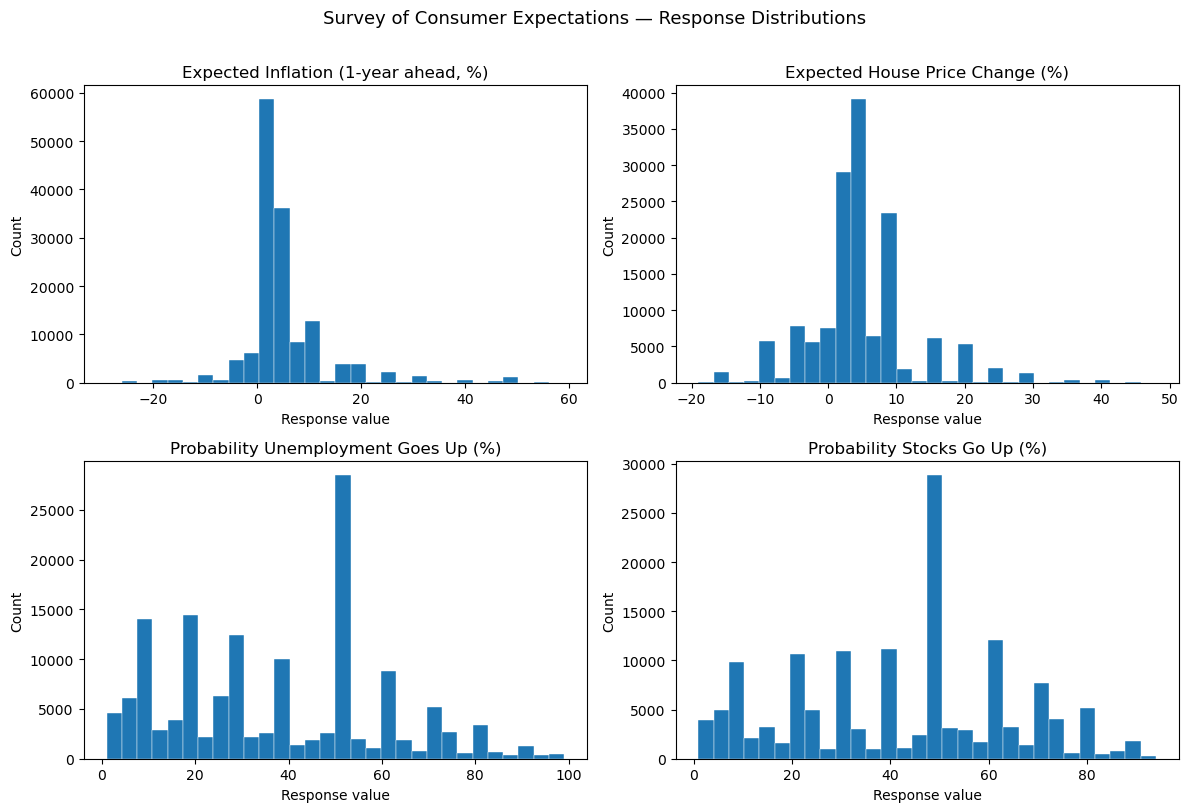

In [363]:
# Step 1 - Histograms of the key expectation variables to visualize their distributions after cleaning
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_vars = [
    ('infl_1y',           'Expected Inflation (1-year ahead, %)'),
    ('house_price_change', 'Expected House Price Change (%)'),
    ('prob_unrate_up',    'Probability Unemployment Goes Up (%)'),
    ('prob_stocks_up',    'Probability Stocks Go Up (%)'),
]

for ax, (col, title) in zip(axes.flat, plot_vars):
    ax.hist(sce_data[col].dropna(), bins=30, edgecolor='white', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel('Response value')
    ax.set_ylabel('Count')

fig.suptitle('Survey of Consumer Expectations — Response Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

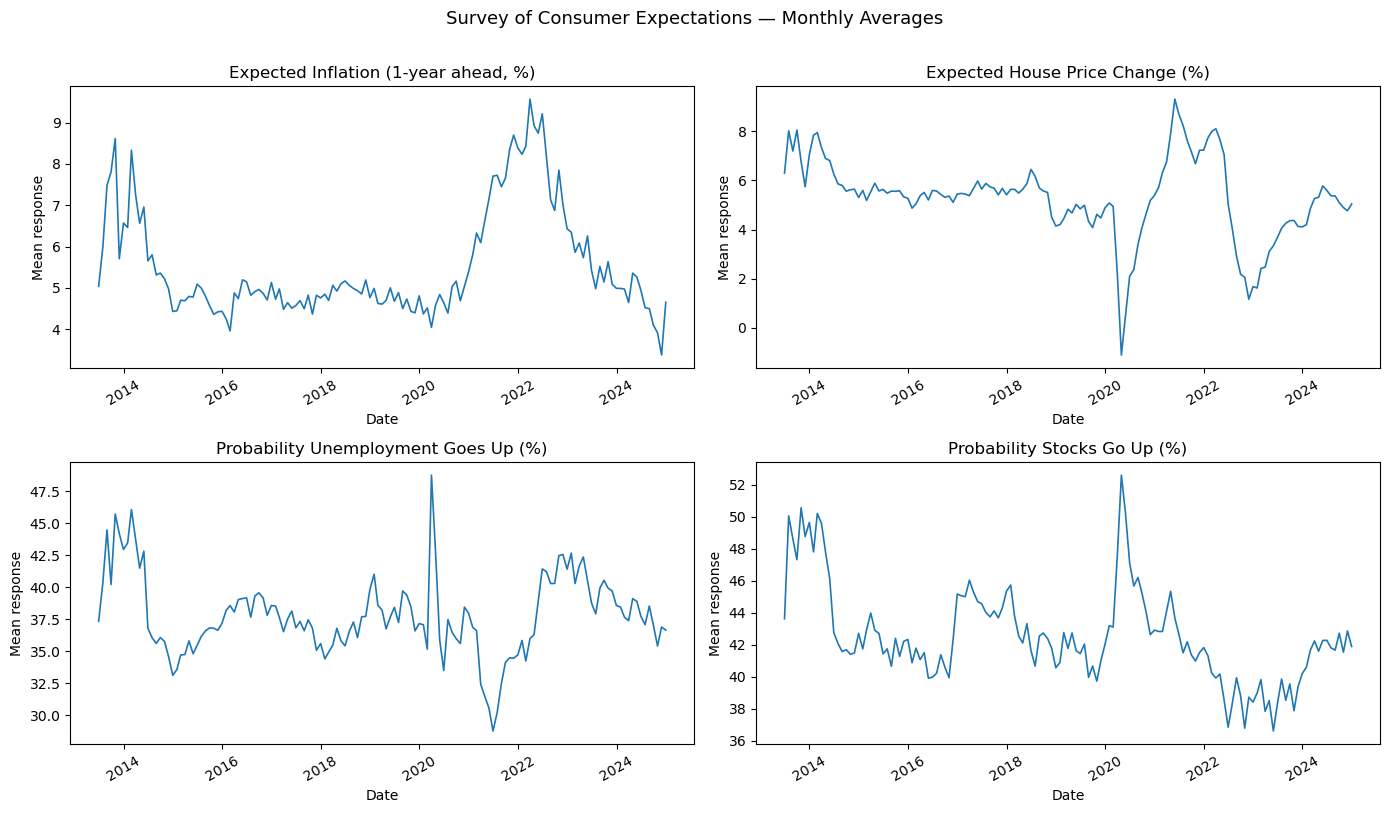

In [364]:
# Step 2 - Time series plots of the key expectation variables (monthly averages) to visualize trends and cycles
monthly_means = (
    sce_data
    .groupby(pd.Grouper(key='date', freq='ME'))[['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']]
    .mean()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ts_vars = [
    ('infl_1y',           'Expected Inflation (1-year ahead, %)'),
    ('house_price_change', 'Expected House Price Change (%)'),
    ('prob_unrate_up',    'Probability Unemployment Goes Up (%)'),
    ('prob_stocks_up',    'Probability Stocks Go Up (%)'),
]

for ax, (col, title) in zip(axes.flat, ts_vars):
    ax.plot(monthly_means.index, monthly_means[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean response')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Survey of Consumer Expectations — Monthly Averages', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

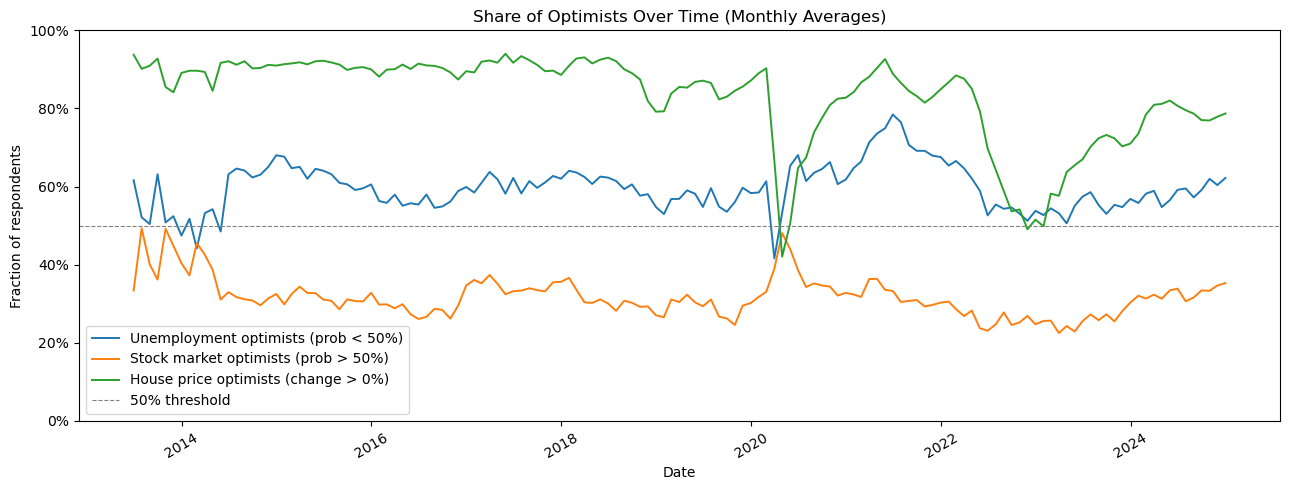

In [365]:
# Step 3 - Plot the share of optimists over time (monthly averages) to visualize trends and cycles in optimism
# Labels for the optimism indicators
opt_labels = {
    'optimist_unrate':      'Unemployment optimists (prob < 50%)',
    'optimist_stocks':      'Stock market optimists (prob > 50%)',
    'optimist_house_price': 'House price optimists (change > 0%)',
}

# Compute monthly means of the optimism indicators
optimism_means = (
    sce_data
    .groupby(pd.Grouper(key='date', freq='ME'))[OPTIMISM_COLS]
    .mean()
)

# Initialize the plot
fig, ax = plt.subplots(figsize=(13, 5))

# Plot each optimism indicator over time
for col in OPTIMISM_COLS:
    ax.plot(optimism_means.index, optimism_means[col], linewidth=1.4, label=opt_labels[col])

# Format y-axis as percentages, set limits, add a horizontal line at 50%, and finalize the plot
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('Date')
ax.set_ylabel('Fraction of respondents')
ax.set_title('Share of Optimists Over Time (Monthly Averages)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

_ = plt.tight_layout()

In [366]:
# Descriptive statistics for expectation variables
desc_stats = sce_data[COLS_EXPECTATIONS + OPTIMISM_COLS].describe().T

display(desc_stats)

,count,mean,std,min,25%,50%,75%,max
infl_1y,145517.0,5.409091,8.510966,-29.0,2.0,3.0,6.0,59.0
house_price_change,145517.0,5.179010,7.787402,-19.0,2.0,5.0,10.0,48.0
prob_unrate_up,145517.0,37.373482,22.170789,1.0,20.0,39.0,50.0,99.0
prob_stocks_up,145517.0,42.116076,22.230797,1.0,23.0,49.0,60.0,94.0
optimist_unrate,145517.0,0.601689,0.489552,0.0,0.0,1.0,1.0,1.0
optimist_stocks,145517.0,0.309380,0.462239,0.0,0.0,0.0,1.0,1.0
optimist_house_price,145517.0,0.831181,0.374593,0.0,1.0,1.0,1.0,1.0


## Part 4 - Exploratory Data Analysis (Macro/Finance)

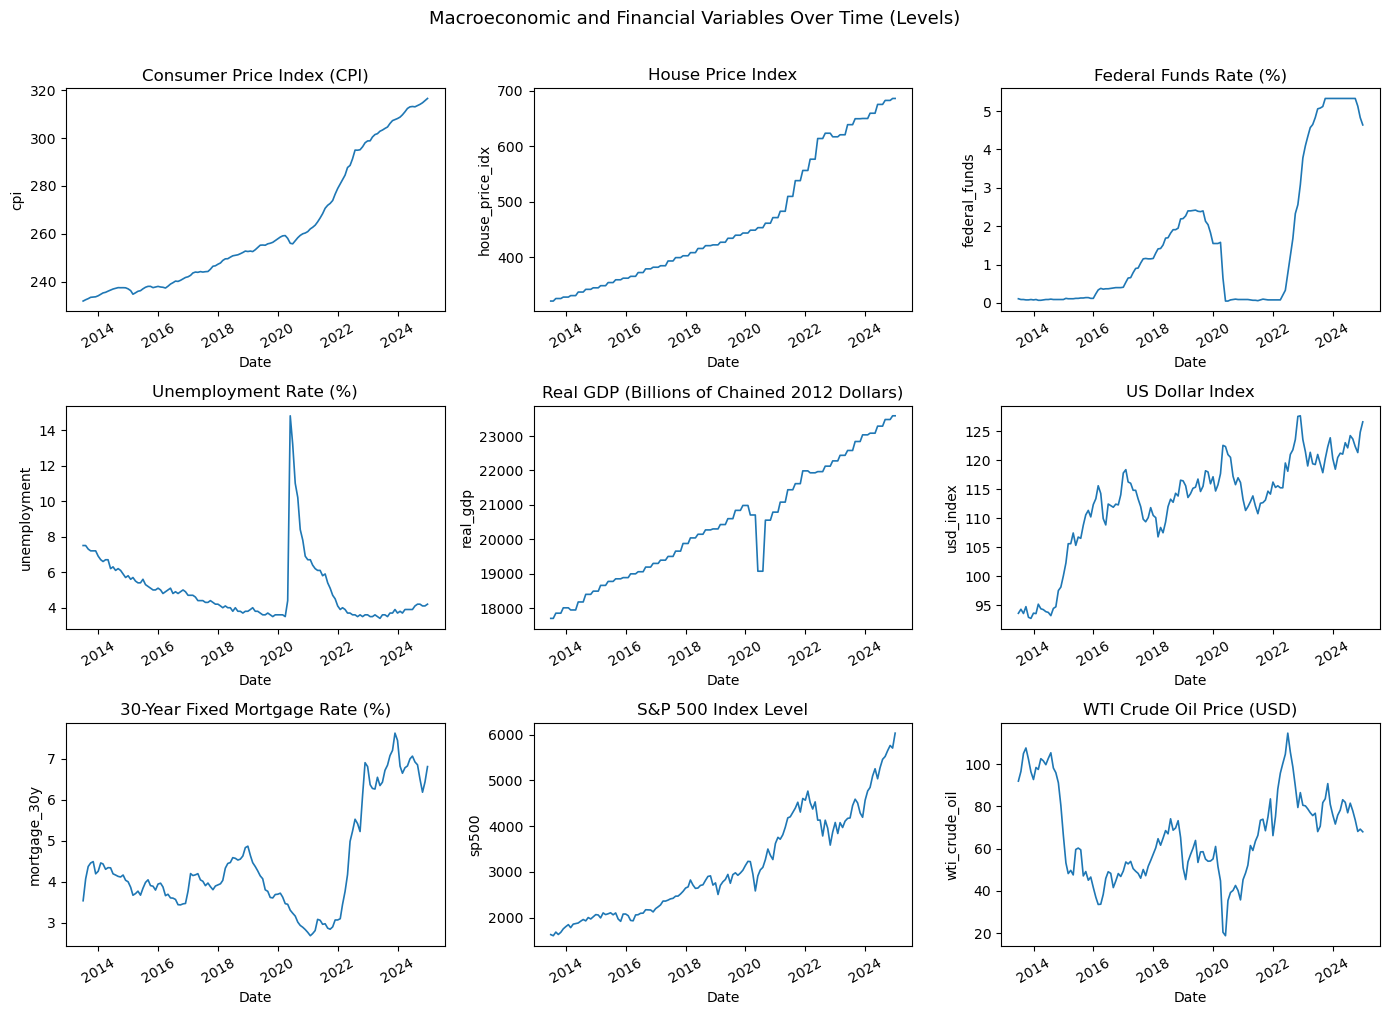

In [367]:
# Step 1 - Plot macro/finance variables in levels over time
# Variables to plot with their corresponding titles
macro_vars = [
    ('cpi', 'Consumer Price Index (CPI)'),
    ('house_price_idx', 'House Price Index'),
    ('federal_funds', 'Federal Funds Rate (%)'),
    ('unemployment', 'Unemployment Rate (%)'),
    ('real_gdp', 'Real GDP (Billions of Chained 2012 Dollars)'),
    ('usd_index', 'US Dollar Index'),
    ('mortgage_30y', '30-Year Fixed Mortgage Rate (%)'),
    ('sp500', 'S&P 500 Index Level'),
    ('wti_crude_oil', 'WTI Crude Oil Price (USD)')
]

# Initialize a 3x3 grid of subplots for the macro/finance variables
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# Loop through the macro and finance variables and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Macroeconomic and Financial Variables Over Time (Levels)', fontsize=13, y=1.01)

_ = plt.tight_layout()

In [368]:
display(macro_all.head())

,cpi,cpi_yoy,house_price_idx,federal_funds,unemployment,real_gdp,usd_index,mortgage_30y,wti_crude_oil,wti_crude_oil_ret,wti_crude_oil_ret_12m,sp500,sp500_ret,sp500_ret_12m
date,,,,,,,,,,,,,,
2013-06-30,231.893,1.390389,321.03,0.11,7.5,17709.671,93.6076,3.536,91.970001,-0.015943,0.062868,1630.739990,0.020763,0.244526
2013-07-31,232.445,1.715794,321.03,0.09,7.5,17709.671,94.3047,4.070,96.559998,0.049908,0.136535,1606.280029,-0.014999,0.179215
2013-08-31,232.900,1.885472,325.58,0.09,7.3,17860.450,93.5703,4.370,105.029999,0.087717,0.192710,1685.729980,0.049462,0.222146
2013-09-30,233.456,1.538809,325.58,0.08,7.2,17860.450,94.7541,4.456,107.650002,0.024945,0.115891,1632.969971,-0.031298,0.160951
2013-10-31,233.544,1.094734,325.58,0.08,7.2,17860.450,92.9207,4.490,102.330002,-0.049419,0.109990,1681.550049,0.029750,0.167200


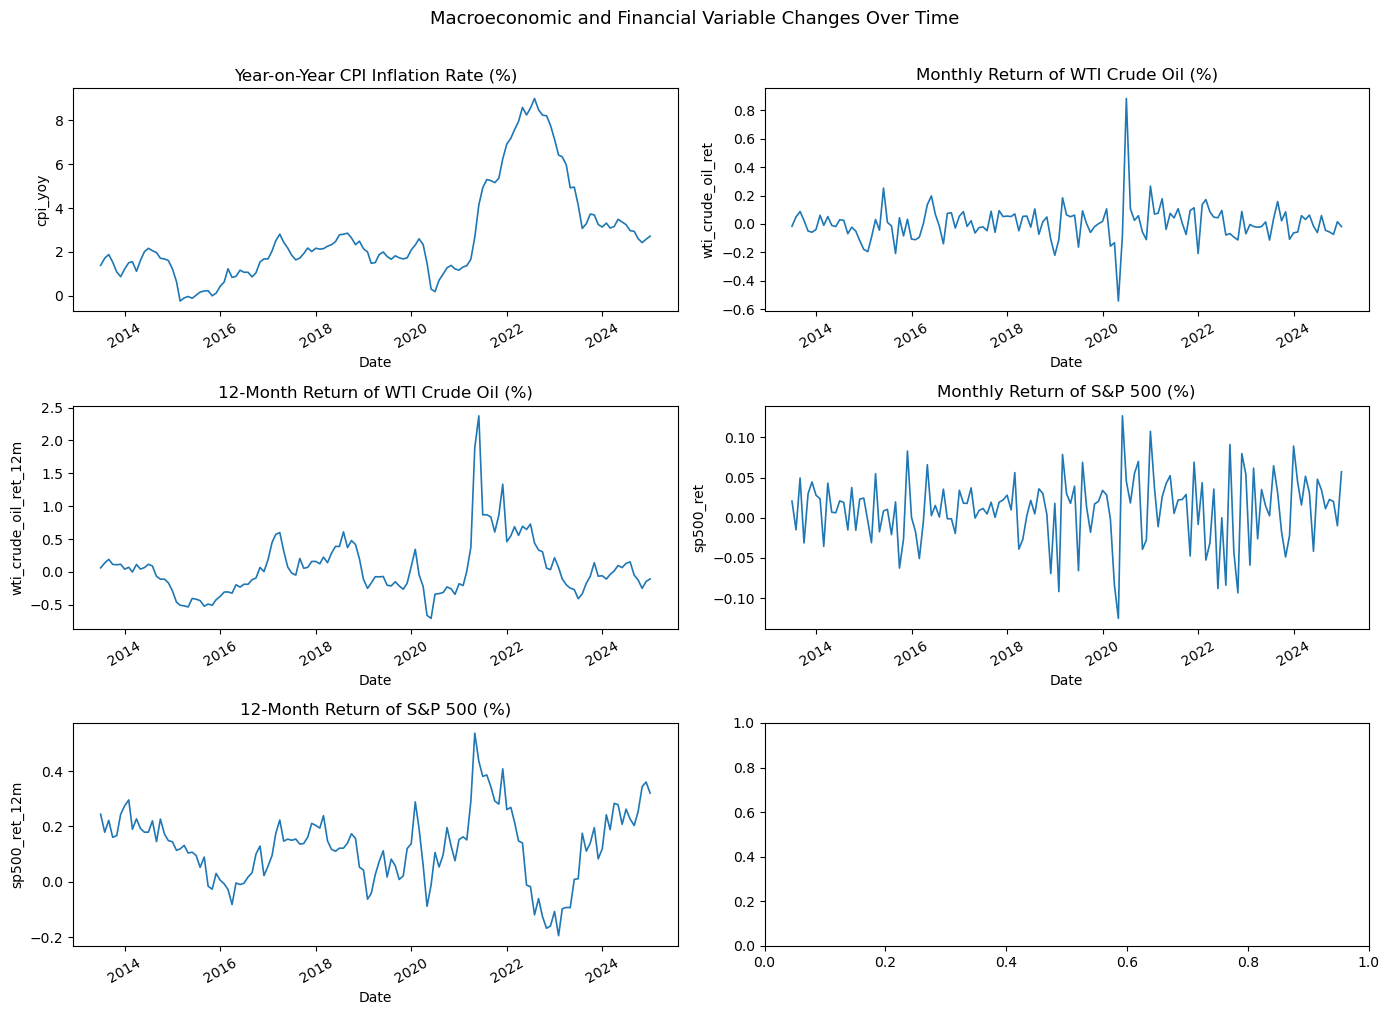

In [369]:
# Step 2 - Plot macro/finance variables in relative/absolute changes over time (where applicable)
# Variables to plot with their corresponding titles and whether to plot returns or levels
macro_vars_changes = [
    ('cpi_yoy', 'Year-on-Year CPI Inflation Rate (%)'),
    ('wti_crude_oil_ret', 'Monthly Return of WTI Crude Oil (%)'),
    ('wti_crude_oil_ret_12m', '12-Month Return of WTI Crude Oil (%)'),
    ('sp500_ret', 'Monthly Return of S&P 500 (%)'),
    ('sp500_ret_12m', '12-Month Return of S&P 500 (%)'),
]

# Initialize a grid of subplots for the macro/finance variables in changes
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Loop through the variables and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars_changes):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Macroeconomic and Financial Variable Changes Over Time', fontsize=13, y=1.01)

_ = plt.tight_layout()

## Part 5 - Predicting Continous Expectation Variables

## Part 6 - Predictinh Binary Optimism Variables (Classification)

## Part 7 - Conclusion